In [26]:
import mne
from pathlib import Path
import json
import matplotlib.pyplot as plt

mne.set_log_level("CRITICAL")

In [32]:
base = Path("../attributions")

save_base = Path("./figures")
save_base.mkdir(exist_ok=True)

transparent = False

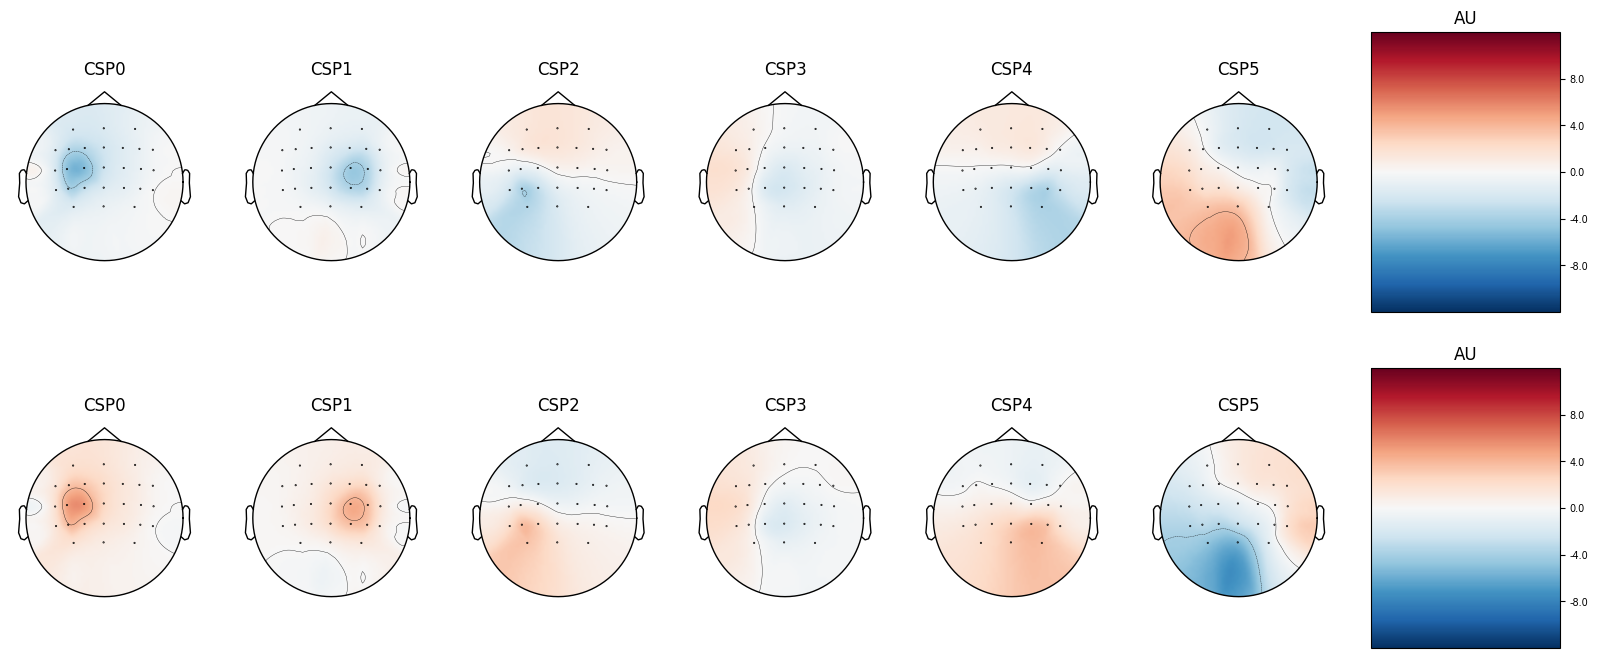

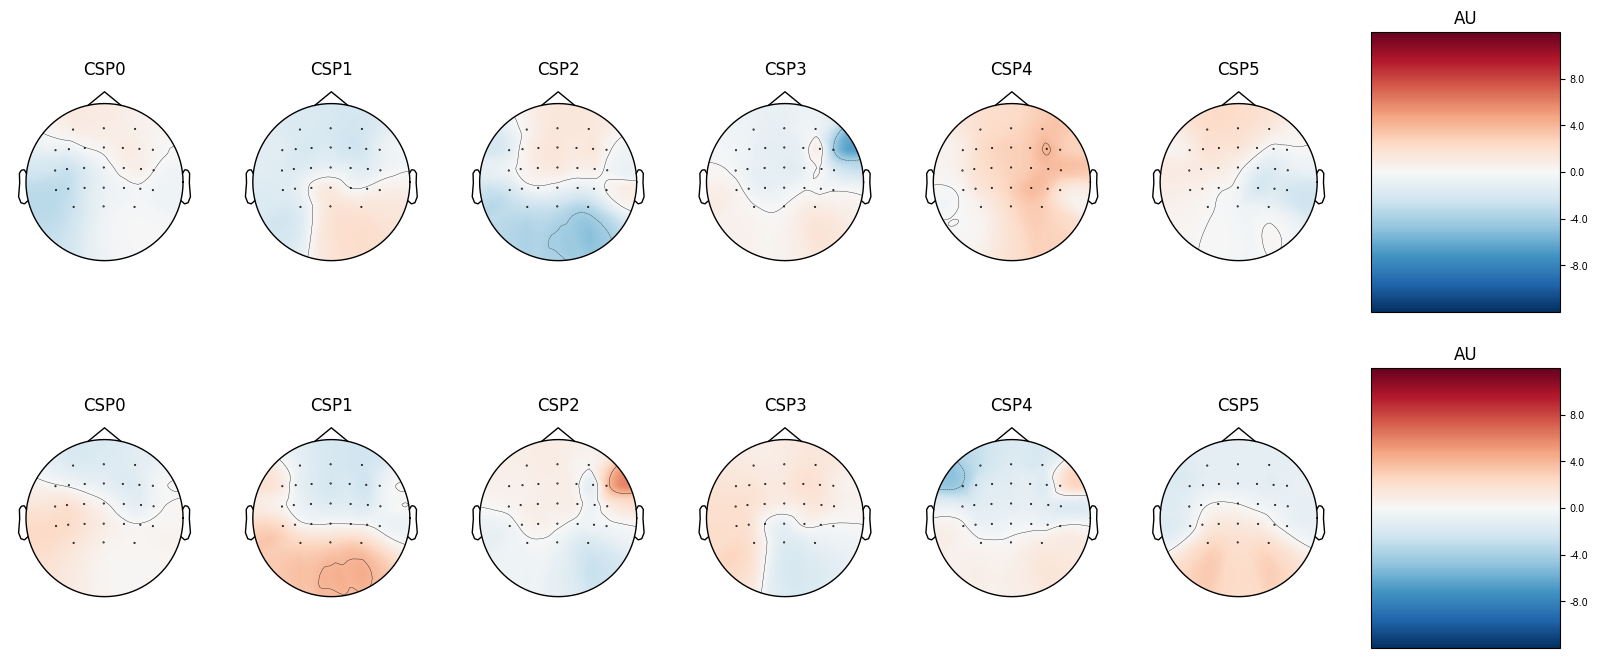

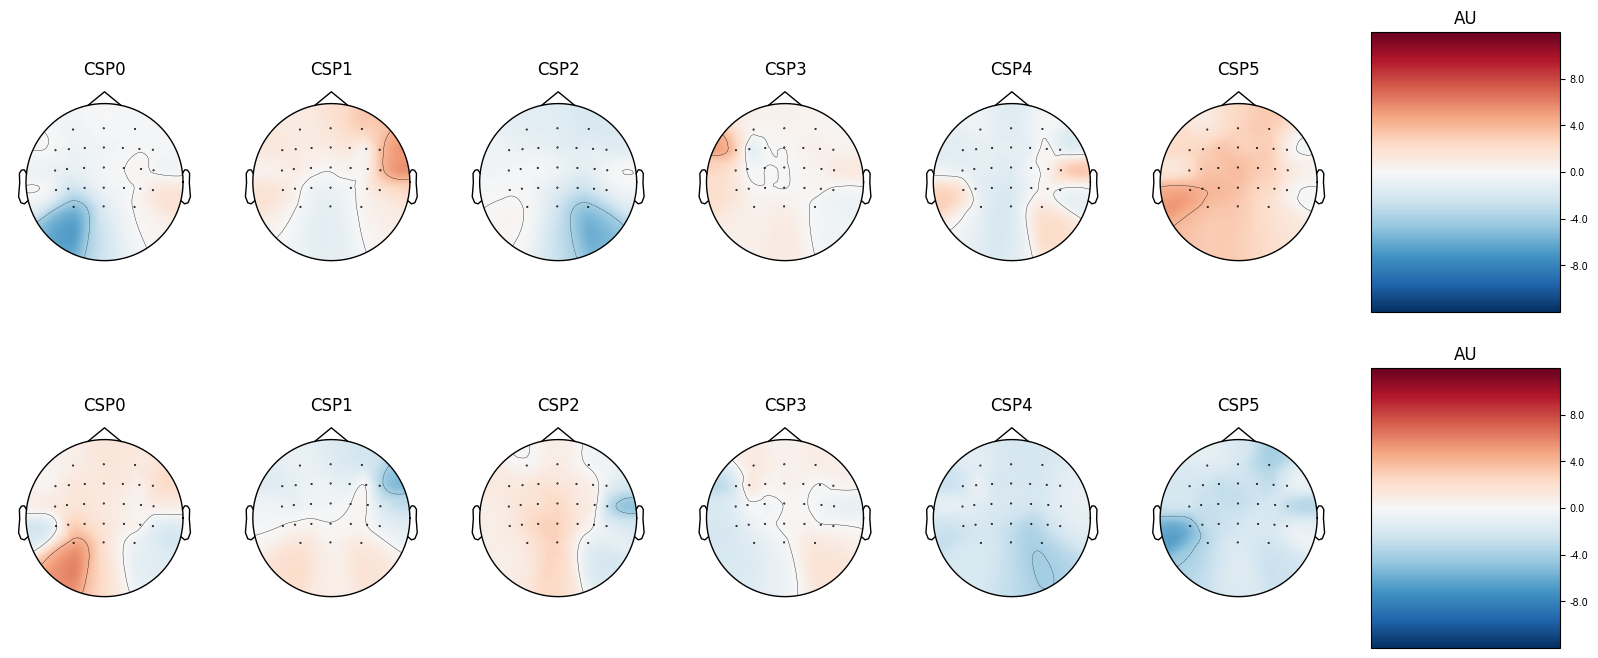

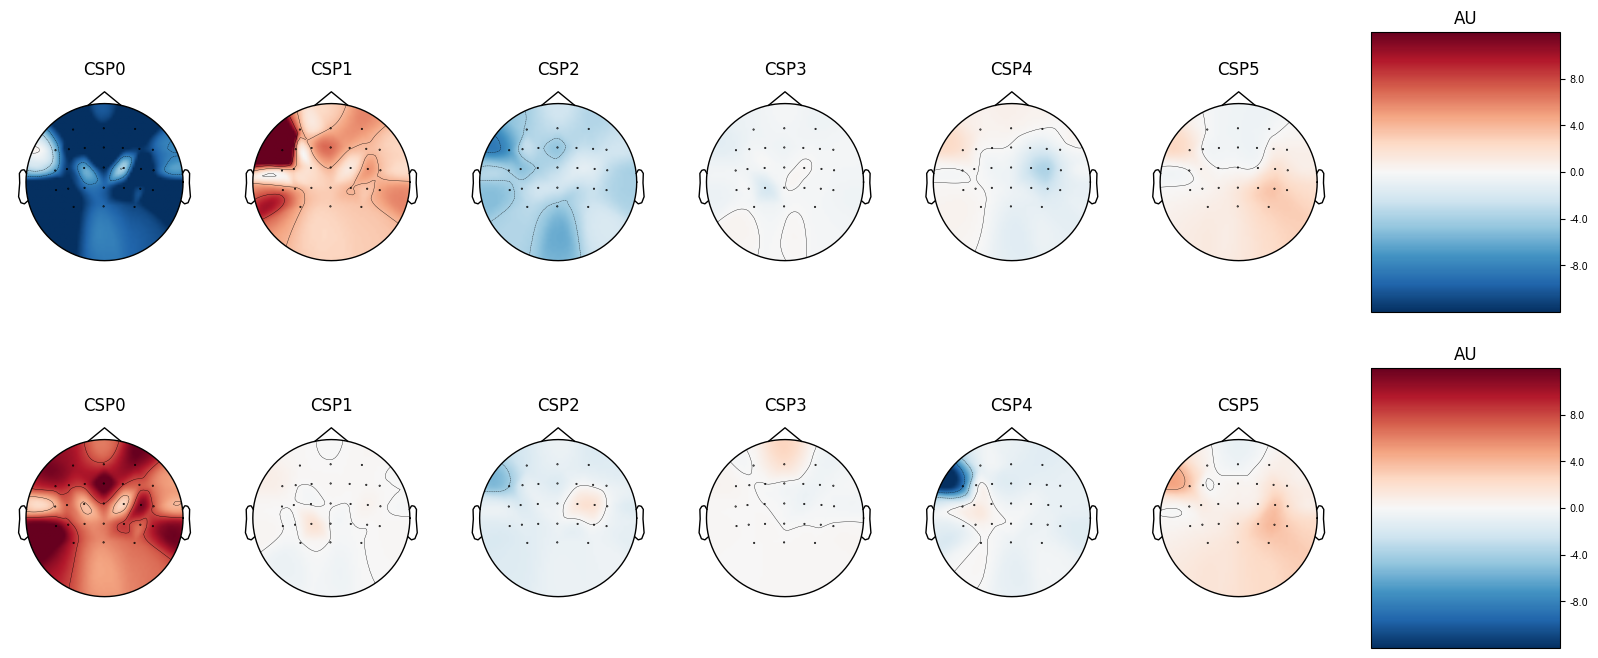

In [34]:
def plot_spatial_pattern(dataset, subject, windows=["W_00_40", "w_05_45"], montage="standard_1005", axes=None,
                         vlim=None, base=Path("./"), mode="within"):
    if axes is None:
        fig, axes = plt.subplots(2, 7)

    with open(f"../Dataset/{dataset}/meta_data.json", "r") as f:
        info = json.load(f)
    ch_names = info["ch_names"]

    info = mne.create_info(ch_names, 1000.0, "eeg")
    info.set_montage(montage)

    for idx, window in enumerate(windows):
        fname = base / f"CSP_LDA_{mode}_{dataset}_{window}_{subject}.hdf5"
        csp = mne.decoding.read_csp(fname)
        csp.plot_patterns(info, components=[0, 1, 2, 3, 4, 5], axes=axes[idx, :], show=False, vlim=vlim)

    """
    montage = mne.channels.make_standard_montage(montage)
    ch_pos = montage.get_positions()["ch_pos"]
    ch_pos = np.array([ch_pos[ch_name][:2] for ch_name in ch_names])

    if ylim is not None:
        im, _ = mne.viz.plot_topomap(saliency_spatial.mean(0), ch_pos, names=ch_names, cmap="Reds", axes=ax, show=False,
                                     vlim=ylim)
    else:
        im, _ = mne.viz.plot_topomap(saliency_spatial.mean(0), ch_pos, names=ch_names, cmap="Reds", axes=ax, show=False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Saliency in %", rotation=270, labelpad=30)
    """


vlim = [-12, 12]

fig, axes = plt.subplots(2, 7, figsize=(20, 8))
subject = 10
plot_spatial_pattern("Dreyer2023", subject, windows=["w_00_40", "w_05_45"], base=base, mode="within", axes=axes,
                     vlim=vlim)
fig.savefig(save_base / f"Dreyer2023_CSP_LDA_Spatial_Pattern_within_{subject}.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 7, figsize=(20, 8))
subject = 11
plot_spatial_pattern("Dreyer2023", subject, windows=["w_00_40", "w_05_45"], base=base, mode="within", axes=axes,
                     vlim=vlim)
fig.savefig(save_base / f"Dreyer2023_CSP_LDA_Spatial_Pattern_within_{subject}.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 7, figsize=(20, 8))
subject = 12
plot_spatial_pattern("Dreyer2023", subject, windows=["w_00_40", "w_05_45"], base=base, mode="within", axes=axes,
                     vlim=vlim)
fig.savefig(save_base / f"Dreyer2023_CSP_LDA_Spatial_Pattern_within_{subject}.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 7, figsize=(20, 8))
subject = 12
plot_spatial_pattern("Dreyer2023", subject, windows=["w_00_40", "w_05_45"], base=base, mode="cross", axes=axes,
                     vlim=vlim)
fig.savefig(save_base / f"Dreyer2023_CSP_LDA_Spatial_Pattern_cross_{subject}.png", dpi=300, transparent=transparent)

